# Loading libraries

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/vscode/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Load data

In [2]:
# Load data
corpus = pd.read_excel('cleaned_corpus.xlsx')

# Convert date_published as datetime data type
corpus['date_published'] = pd.to_datetime(
  corpus['date_published']
)

## Inspecting the data

In [3]:
corpus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851 entries, 0 to 850
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   title            851 non-null    object        
 1   link             851 non-null    object        
 2   date_published   851 non-null    datetime64[ns]
 3   text             850 non-null    object        
 4   source           851 non-null    object        
 5   like_count       826 non-null    float64       
 6   reply_parent_id  98 non-null     object        
 7   cleaned_text     838 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 53.3+ KB


In [4]:
display(
  corpus.head()
)
display(
  corpus.tail()
)

,title,link,date_published,text,source,like_count,reply_parent_id,cleaned_text
0,Hindi Ito Marites: The Hague and Filipinos' pu...,https://www.rappler.com/newsbreak/podcasts-vid...,2025-08-15 16:00:29,"When local courts offer no refuge, or when fac...",rappler,NaN,NaN,local court offer refuge face formid foreign a...
1,FACT CHECK: No Guinness record of Duterte as ‘...,https://www.rappler.com/newsbreak/fact-check/n...,2025-08-12 10:00:00,Claim: Former president Rodrigo Duterte holds ...,rappler,NaN,NaN,claim former presid rodrigo dutert hold guin w...
2,WATCH: Tuloy ba ang pre-trial hearing ni Duter...,https://www.rappler.com/philippines/video-will...,2025-08-11 19:00:00,"MANILA, Philippines – May bagong hiling ang de...",rappler,NaN,NaN,manila philippin may bagong hile ang defens te...
3,Duterte team wants ICC Prosecutor Khan disqual...,https://www.rappler.com/video/daily-wrap/augus...,2025-08-08 22:07:53,Here are today’s headlines – the latest news i...,rappler,NaN,NaN,today headlin latest news philippin around wor...
4,Duterte team wants Prosecutor Khan disqualifie...,https://www.rappler.com/philippines/duterte-de...,2025-08-08 07:00:00,"MANILA, Philippines – Prosecutor Karim Khan, o...",rappler,NaN,NaN,manila philippin prosecutor karim khan leav in...


,title,link,date_published,text,source,like_count,reply_parent_id,cleaned_text
846,Ul*l dignified. Pinapakyuhan nga si Bong Daza ...,https://www.youtube.com/watch?v=yfoq-0gGTLM&lc...,2024-08-27 19:24:46,Ul*l dignified. Pinapakyuhan nga si Bong Daza ...,youtube,0.0,UgwBBzeGtqWna6y4KUJ4AaABAg,ul l dignified pinapakyuhan nga si bong daza s...
847,"That vp is rude, entitled and arrogant like he...",https://www.youtube.com/watch?v=yfoq-0gGTLM&lc...,2024-08-27 21:13:32,"That vp is rude, entitled and arrogant like he...",youtube,3.0,UgwBBzeGtqWna6y4KUJ4AaABAg,vp rude entitl arrog like father they r use sp...
848,What country is this? Very interesting.,https://www.youtube.com/watch?v=yfoq-0gGTLM&lc...,2024-08-27 22:16:52,What country is this? Very interesting.,youtube,0.0,UgwBBzeGtqWna6y4KUJ4AaABAg,countri this veri interesting
849,@@cvoutdoors9859palamunin,https://www.youtube.com/watch?v=yfoq-0gGTLM&lc...,2024-08-27 23:14:26,@@cvoutdoors9859palamunin,youtube,0.0,UgwBBzeGtqWna6y4KUJ4AaABAg,cvoutdoors palamunin
850,That’s true,https://www.youtube.com/watch?v=yfoq-0gGTLM&lc...,2024-08-28 02:00:32,That’s true,youtube,0.0,UgwBBzeGtqWna6y4KUJ4AaABAg,that true


# Counts & Percentages

In [5]:
corpus['source'].value_counts(normalize=True)

source
youtube    0.970623
rappler    0.029377
Name: proportion, dtype: float64

<Axes: xlabel='source', ylabel='count'>

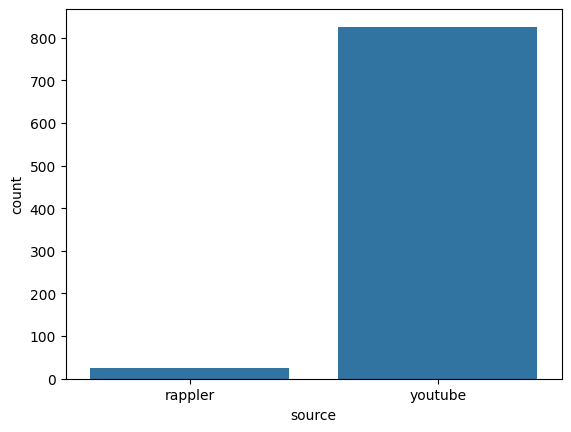

In [8]:
sns.countplot(data=corpus, x='source')

In [15]:
x = corpus[['date_published', 'source']]
x

,date_published,source
0,2025-08-15 16:00:29,rappler
1,2025-08-12 10:00:00,rappler
2,2025-08-11 19:00:00,rappler
3,2025-08-08 22:07:53,rappler
4,2025-08-08 07:00:00,rappler
...,...,...
846,2024-08-27 19:24:46,youtube
847,2024-08-27 21:13:32,youtube
848,2024-08-27 22:16:52,youtube
849,2024-08-27 23:14:26,youtube


In [18]:
# Group by date (yyyy-mm-dd) and source
# Pivot the grouped data to have sources as columns and dates as index
pivot_counts = counts_by_date_source.pivot(
  index='date_published',
  columns='source',
  values='count'
).fillna(0).astype(int)
display(pivot_counts)

source,rappler,youtube
date_published,,
2024-08-27,0,22
2024-08-28,0,12
2024-08-29,0,1
2024-09-04,0,2
2025-03-16,0,428
2025-03-17,0,181
2025-03-18,0,55
2025-03-19,0,28
2025-03-20,0,19


In [ ]:
# Group by date based on date_published (date_published is timestamp)

,date_published,source,count
0,2024-08-27 18:57:10,youtube,1
1,2024-08-27 18:59:59,youtube,1
2,2024-08-27 19:00:55,youtube,1
3,2024-08-27 19:05:47,youtube,1
4,2024-08-27 19:08:24,youtube,1
...,...,...,...
844,2025-08-08 07:00:00,rappler,1
845,2025-08-08 22:07:53,rappler,1
846,2025-08-11 19:00:00,rappler,1
847,2025-08-12 10:00:00,rappler,1
